# Exercise 4 — What if the target is not what we expected?

*Covers notebooks 03–04. Difficulty: ★★★☆☆*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

### 4.1 — Plan the observation

A SN Ia is predicted at $z=0.9$, at maximum, with $x_1=0$ and $c=0$. Set up the instrument to
reach SNR=12 (per resolution element, rest-frame 4000–7000 Å) and note the exposure time.

In [2]:
snr_range = dict(lbda_range=[4000, 7000], frame="rest")
snia = slicersim.LazuliSupernova(redshift=0.9, x1=0, c=0, phase=0)
config, snr = snia.setup_to_snr(12, **snr_range)
print(config, f"SNR={snr:.1f}", f"{snia.get_exposure_time()/3600:.2f} h")

{'nmd': (64, 8, 0), 'nramps': 2} SNR=10.6 0.80 h


### 4.2 — Reality check

The true properties are uncertain: $z \sim \mathcal{U}(0.85, 0.95)$,
phase $\sim \mathcal{U}(-5, 10)$ days, $x_1 \sim \mathcal{N}(0, 1)$, $c \sim \mathcal{N}(0, 0.1)$.
Draw 30 realisations and compute the SNR actually reached **with the planned configuration**.
Plot the histogram. Which fraction reaches SNR ≥ 10?

fraction with SNR >= 10: 53%


[Text(0.5, 0, 'reached SNR'), Text(0, 0.5, 'number of realisations')]

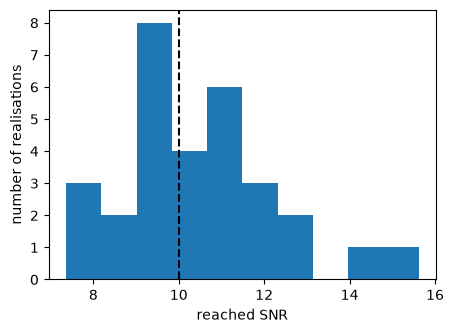

In [3]:
rng = np.random.default_rng(42)

def draw_snr(target, ndraw=30):
    snrs = []
    for _ in range(ndraw):
        target.change_properties(redshift=rng.uniform(0.85, 0.95), phase=rng.uniform(-5, 10),
                                 x1=rng.normal(0, 1), c=rng.normal(0, 0.1))
        snrs.append(target.get_band_snr(**snr_range))
    target.change_properties(redshift=0.9, phase=0, x1=0, c=0)  # back to the prediction
    return np.asarray(snrs)

snrs = draw_snr(snia)
print(f"fraction with SNR >= 10: {np.mean(snrs >= 10):.0%}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(snrs, bins=10)
ax.axvline(10, color="k", ls="--")
ax.set(xlabel="reached SNR", ylabel="number of realisations")

### 4.3 — Safety margin

Which planning SNR (try 12, 14, 16) guarantees that at least 90% of the realisations reach
SNR ≥ 10? What does it cost in exposure time?

In [4]:
for snr_plan in [12, 14, 16]:
    _ = snia.setup_to_snr(snr_plan, **snr_range)
    snrs = draw_snr(snia)
    print(f"plan SNR={snr_plan}: {snia.get_exposure_time()/3600:.2f} h, "
          f"fraction >= 10: {np.mean(snrs >= 10):.0%}")

plan SNR=12: 0.80 h, fraction >= 10: 63%


plan SNR=14: 1.61 h, fraction >= 10: 97%


plan SNR=16: 1.61 h, fraction >= 10: 100%


### 4.4 — End of life

How much longer does it take to reach SNR=10 with the end-of-life instrument
(`change_configuration("eol")`) compared to the current best estimate (`"cbe"`), at redshifts
0.5, 0.9 and 1.3?

In [5]:
import warnings
warnings.filterwarnings("ignore", message=".*not.*mutable")

for redshift in [0.5, 0.9, 1.3]:
    snia.change_properties(redshift=redshift)
    exptime = {}
    for configuration in ["cbe", "eol"]:
        snia.change_configuration(configuration)
        _ = snia.setup_to_snr(10, **snr_range)
        exptime[configuration] = snia.get_exposure_time()
    print(f"z={redshift}: EOL/CBE exposure time = {exptime['eol'] / exptime['cbe']:.1f}")
snia.change_configuration("cbe")

z=0.5: EOL/CBE exposure time = 1.8


z=0.9: EOL/CBE exposure time = 2.5


z=1.3: EOL/CBE exposure time = 4.0


### 4.5 — Limiting magnitude

Using a flat spectrum (`LazuliTarget`), find the `sdssr` magnitude at which the SNR (per
resolution element, 7000–8000 Å observer frame) is 5, for one ramp `(64, 8, 0)`, and for 4 such
ramps. How much deeper do 4 ramps go? Compare with what you expect if the noise is dominated by
the detector.

*Hint: scan the magnitude and interpolate.*

In [6]:
lbda_in = np.arange(3000, 20_000, 1.0)
flat = slicersim.LazuliTarget(lbda_in, np.ones_like(lbda_in), mag=22, band="sdssr")
mags = np.arange(21, 26.1, 0.5)

limits = {}
for nramps in [1, 4]:
    flat.change_detector(nmd=(64, 8, 0), nramps=nramps)
    snrs = []
    for mag in mags:
        flat.change_properties(mag=mag)
        snrs.append(flat.get_band_snr([7000, 8000], frame="obs"))
    limits[nramps] = np.interp(5, snrs[::-1], mags[::-1])  # SNR decreases with mag
    print(f"{nramps} ramp(s): SNR=5 at r = {limits[nramps]:.2f}")

print(f"gain: {limits[4] - limits[1]:.2f} mag; detector-dominated expectation: "
      f"SNR ∝ flux × sqrt(nramps) -> 2.5 log10(2) = {2.5 * np.log10(2):.2f} mag")

1 ramp(s): SNR=5 at r = 24.54


4 ramp(s): SNR=5 at r = 25.39
gain: 0.85 mag; detector-dominated expectation: SNR ∝ flux × sqrt(nramps) -> 2.5 log10(2) = 0.75 mag
